# Project 3 · 02：手搓一个迷你编译器——从「逐算子解释」到「生成专用代码」

> **一句话心智模型：** 编译器干的三件事是 **分析**（把"要算什么"拆成一张图）、**变换**（在不改变结果的前提下重排与合并）、**生成**（产出一段专用代码，而不是运行时边查表边解释）。

Project 3 的 01 直接从 TVM Relax 的 **Backend Contract**（我们和后端之间签的"哪些子图归你、要满足什么条件"的约定）开始。但如果你没有亲手把
`解释执行 → 融合 → 代码生成` 走一遍，后面遇到的 `FuseOps` / `TIR` / `codegen` 就只是三个名字。

这本 notebook 用**纯 Python + 一段 C**，把这三个动作全部手搓一遍，并且**每一步都用可测量的数字证明它到底省了什么**。

---

## 需求（我们从这里出发）

要在机器上反复计算

$$y = \sin\big(\mathrm{relu}(xW + b)\big)$$

目标是：**快**、**省内存**、**换硬件时不要重写全部代码**。

## 本 notebook 要回答的问题

| # | 问题 | 对应章节 |
|---|---|---|
| 1 | 一个"计算"在编译器眼里到底是什么数据结构？ | §1 |
| 2 | 最朴素的"逐算子解释执行"，开销花在哪？ | §2 §3 |
| 3 | 算子融合省掉的到底是计算量，还是别的什么？ | §4 |
| 4 | "解释执行"和"编译执行"的本质区别是什么？ | §5 |
| 5 | 生成出来的代码本身还能被优化吗（tiling）？ | §6 |
| 6 | 手搓完之后还缺什么？——那正是 TVM 存在的理由 | §7 |

## 实验合同（先定死，避免事后挑数字）

- `seed = 7`，`dtype = float32`，图固定为 `matmul → add(bias) → relu → sin`
- **主证据是「中间张量字节数」与「生成代码的耗时」，不是端到端延迟**——Python 解释器开销会淹没小算子的收益
- 手写的 C kernel **不与 numpy/BLAS 比加速比**（那必然输，属于伪证据）；只在**我们自己生成的两种 C 代码之间**比
- 任何数字之前先过 **parity**（与 numpy 参考逐元素比对）
- 融合前后求和顺序变化会带来 ~1e-4 量级的 float32 差异，这是**编译器改变计算顺序的正常代价**，不是 bug

---

## §1 分析：一个"计算"在编译器眼里是什么

先别急着写代码。看这个式子：

$$y = \sin\big(\mathrm{relu}(xW + b)\big)$$

它其实由三样东西组成：

| 组成 | 这里具体是什么 | 类比你已有的知识 |
|---|---|---|
| **数据**（tensor） | `x`、`W`、`b`，以及每一步算出来的中间结果 | 内存里的一块连续 buffer |
| **算子**（op） | `matmul`、`add`、`relu`、`sin` | 一个纯函数：读几块内存，写一块内存 |
| **依赖**（edge） | `relu` 必须等 `add` 算完；`add` 必须等 `matmul` | Makefile 的依赖边、OS 的进程等待图、CPU 的指令相关 |

把"数据"当节点、"算子 + 它消费的数据"也当节点，就得到一张**有向无环图（DAG）**，工程上叫**数据流图 / dataflow graph**。

**为什么必须是 DAG？** 因为有了环就无法确定执行顺序（谁先算？），也就无法做拓扑排序。这也是为什么 TVM Relax 要把纯计算部分圈进 `DataflowBlock`——**圈进去就等于向编译器承诺"这块里没有控制流、没有环、没有副作用，你可以随便重排、合并、搬走"**。

In [1]:
# ── 数据结构：一张数据流图（DAG）────────────────────────────────
# Node.name   : 这个 tensor 的名字，也是这条"生产"的唯一 ID
# Node.op     : 算子种类；"input" 表示外部喂进来的数据（图的叶子）
# Node.inputs : 它依赖的上游 tensor 名 —— 这就是图里的有向边
# Node.shape  : 静态形状。注意：这里只能硬编码，
#               TVM 里这件事由 StructInfo 自动推导，见 03 号 notebook
from dataclasses import dataclass


@dataclass(frozen=True)
class Node:
    name: str
    op: str
    inputs: tuple = ()
    shape: tuple = ()


def make_graph(m, k, n):
    """构造 x:[m,k] @ w:[k,n] -> +b:[n] -> relu -> sin 这张图"""
    return {
        "x":    Node("x",    "input",  shape=(m, k)),
        "w":    Node("w",    "input",  shape=(k, n)),
        "b":    Node("b",    "input",  shape=(n,)),
        "mm":   Node("mm",   "matmul", ("x", "w"), (m, n)),
        "bias": Node("bias", "add",    ("mm", "b"), (m, n)),
        "relu": Node("relu", "relu",   ("bias",),   (m, n)),
        "sin":  Node("sin",  "sin",    ("relu",),   (m, n)),
    }


def topo(nodes, output):
    """后序遍历求依赖顺序 —— 和 Makefile 求值、指令调度是同一个算法"""
    order, seen = [], set()

    def visit(name):
        if name in seen:
            return
        seen.add(name)
        for dep in nodes[name].inputs:
            visit(dep)
        order.append(name)

    visit(output)
    return order


M, K, N = 8, 16, 16               # 先用小尺寸看清结构，后面再放大做测量
NODES = make_graph(M, K, N)
OUTPUT = "sin"

print("拓扑序 :", " → ".join(topo(NODES, OUTPUT)))
print("节点数 :", len(NODES), " 其中 input:", sum(1 for v in NODES.values() if v.op == "input"))

拓扑序 : x → w → mm → b → bias → relu → sin
节点数 : 7  其中 input: 3


---

## §2 Naive v1：逐算子解释执行

**Naive 想法**：既然图已经排好序了，那就**顺着拓扑序，一个算子一个算子地调函数**。

这就是"解释器"形态：

```text
for node in 拓扑序:
    从 env 里取出它的输入 tensor
    查算子表找到实现
    调用它 → 得到一个完整的输出 tensor
    把输出 tensor 存回 env
```

类比：shell 逐条读命令执行，不做任何跨命令的规划。

**关键代价：每个算子的输出都必须被完整"物化"（materialize）成一个真实的数组放进内存。** 下一个算子再从内存里把它读出来。

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# macOS 的 matplotlib 默认字体不含 CJK 字形，不指定的话图里中文会渲染成方框
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Hiragino Sans GB",
                                   "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SEED = 7            # 实验合同里固定的随机种子
rng = np.random.default_rng(SEED)

# 算子库：op 名 -> 具体实现。解释器运行时靠这张表"查表分派"（dispatch）
OP_IMPL = {
    "matmul": lambda a, b: a @ b,
    "add":    lambda a, b: a + b,
    "relu":   lambda a: np.maximum(a, 0),
    "sin":    np.sin,
}


def run_interpreter(nodes, output, feeds, profile=None, impl=None):
    """逐算子解释执行。
    profile : 传入 list 则记录 (tensor名, op, 输出字节数, 耗时, shape)
    impl    : 算子实现表，默认用 OP_IMPL；跑融合图时传入替换过的表
    """
    impl = impl or OP_IMPL
    env = dict(feeds)
    for name in topo(nodes, output):
        nd = nodes[name]
        if nd.op == "input":
            continue
        args = [env[i] for i in nd.inputs]      # 从内存里把输入读出来
        t0 = time.perf_counter()
        out = impl[nd.op](*args)                # 一次独立的黑盒调用
        dt = time.perf_counter() - t0
        env[name] = out                         # 输出完整写回内存（物化）
        if profile is not None:
            profile.append((name, nd.op, out.nbytes, dt, out.shape))
    return env[output]


def random_feeds(m, k, n):
    return {
        "x": rng.standard_normal((m, k)).astype("float32"),
        "w": rng.standard_normal((k, n)).astype("float32"),
        "b": rng.standard_normal((n,)).astype("float32"),
    }


feeds = random_feeds(M, K, N)
prof = []
y_naive = run_interpreter(NODES, OUTPUT, feeds, prof)

# ── 正确性门禁：先对上 numpy 参考，再谈别的数字 ──
ref = np.sin(np.maximum(feeds["x"] @ feeds["w"] + feeds["b"], 0))
print(f"parity  max|Δ| = {np.abs(y_naive - ref).max():.3e}   shape={y_naive.shape}")

print(f"\n{'tensor':<8}{'op':<9}{'shape':<12}{'bytes':>8}")
for name, op, nbytes, dt, shape in prof:
    print(f"{name:<8}{op:<9}{str(shape):<12}{nbytes:>8}")

parity  max|Δ| = 0.000e+00   shape=(8, 16)

tensor  op       shape          bytes
mm      matmul   (8, 16)          512
bias    add      (8, 16)          512
relu    relu     (8, 16)          512
sin     sin      (8, 16)          512


---

## §3 分析：Naive 的账本——钱花在"中间张量"上

上面那张表里，`mm` / `bias` / `relu` 三个 tensor 是**谁都不想要的**：用户只要最终的 `y`，这三个只是 pipeline 中间的脚手架，却各自占了一块真实的内存。

把 `M=K=N=8/16/16` 这一次的物理内存摊开看（float32 = 4 字节）：

| tensor | shape | 元素数 | 字节 | 谁写它 | 谁读它 | 是不是用户要的 |
|---|---|---|---|---|---|---|
| `mm`   | [8,16] | 128 | 512 | matmul | add | ❌ 中间 |
| `bias` | [8,16] | 128 | 512 | add | relu | ❌ 中间 |
| `relu` | [8,16] | 128 | 512 | relu | sin | ❌ 中间 |
| `sin`  | [8,16] | 128 | 512 | sin | 用户 | ✅ 输出 |

**所以每个中间 tensor 至少要被写 1 次、读 1 次。** 3 个中间 tensor = 6 次 `[8,16]` 的内存往返，而真正的乘法只算了 `8×16×16 = 2048` 次 FMA。

小尺寸下这个浪费不起眼，但**中间张量字节数随 `M·N` 线性增长**，而且真实模型里是一条几十上百层的链。下面把它随规模扫一遍。

In [3]:
def tensor_bytes(shape):
    """float32 = 4 字节；由形状反推字节数，避免真的去分配大数组"""
    n = 1
    for d in shape:
        n *= d
    return n * 4


def account(nodes, output):
    """中间张量账本：除最终输出外，所有被物化的 tensor 的字节数之和"""
    order = topo(nodes, output)
    return sum(tensor_bytes(nodes[t].shape) for t in order[:-1]
               if nodes[t].op != "input")


def count_intermediate(nodes, output):
    """中间张量个数"""
    order = topo(nodes, output)
    return sum(1 for t in order[:-1] if nodes[t].op != "input")


SWEEP = [16, 64, 256, 1024]                        # M=K=N 的扫描档位
naive_bytes = [account(make_graph(s, s, s), "sin") for s in SWEEP]

print(f"{'size(M=K=N)':>12}{'中间张量字节':>16}{'中间张量数':>12}")
for s, b in zip(SWEEP, naive_bytes):
    print(f"{s:>12}{b:>16,}{count_intermediate(make_graph(s, s, s), 'sin'):>12}")

 size(M=K=N)          中间张量字节       中间张量数
          16           3,072           3
          64          49,152           3
         256         786,432           3
        1024      12,582,912           3


---

## §4 改进 1：算子融合（fusion）

**观察**：`matmul → add(bias) → relu` 这一段是**逐元素/可流水**的——`relu` 只依赖 `add` 的同一个位置，`add` 只依赖 `matmul` 的同一个位置。

那能不能**一个循环算完三件事**？

```text
for i in 行:
    for j in 列:
        acc = sum_k X[i,k] * W[k,j]     # matmul
        acc += B[j]                     # add(bias)
        out[i,j] = max(acc, 0)          # relu
```

`acc` 待在**寄存器**里，从头到尾没进过内存。

**这就是融合省下的东西：不是 FLOPs（乘法次数一模一样），而是内存往返。**

> 用你的组成原理知识锚定：这等价于把三次"load–compute–store"压成一次"load–compute–store"，省的是 **DDR 带宽 + 分配器调用**，跟 ALU 无关。这也是为什么端侧优化里，element-wise 算子的瓶颈几乎永远是带宽而不是算力。

In [4]:
# ── 融合器：在图上找"可融合的链"─────────────────────────────
# 手写版只认一条固定的链；TVM 里这件事由 DPL pattern + FuseOpsByPattern 做，见 03/04
FUSE_CHAIN = ("matmul", "add", "relu")


def find_fusable_groups(nodes, output, chain=FUSE_CHAIN):
    """在拓扑序里找 op 类型严格等于 chain 的连续段。
    只看计算节点（input 是叶子，不参与匹配）；
    中间只要被别的算子插一脚（比如一个 reshape），链就断了。"""
    order = [t for t in topo(nodes, output) if nodes[t].op != "input"]
    groups, i = [], 0
    while i < len(order):
        seg, j = [], i
        for want in chain:
            if j < len(order) and nodes[order[j]].op == want:
                seg.append(order[j])
                j += 1
            else:
                seg = []
                break
        if seg:
            groups.append(tuple(seg))
            i = j
        else:
            i += 1
    return groups


def fuse_graph(nodes, groups):
    """图重写（graph rewriting）：把每个融合组塌缩成一个新节点。

    新节点的输入 = 组内节点引用的、但不属于组本身的 tensor（即组的外部输入）。
    组里最后一个节点的名字被"改名"成新节点名，下游引用自动跟过来。
    真实编译器的 fusion pass 做的正是这件事。"""
    member = {n for g in groups for n in g}
    rename = {g[-1]: f"fused{i}" for i, g in enumerate(groups)}
    new = {n: Node(n, nd.op, tuple(rename.get(i, i) for i in nd.inputs), nd.shape)
           for n, nd in nodes.items() if n not in member}
    for i, g in enumerate(groups):
        ext = []
        for n in g:
            for d in nodes[n].inputs:
                if d not in member and d not in ext:
                    ext.append(d)
        new[f"fused{i}"] = Node(f"fused{i}", "fused", tuple(ext), nodes[g[-1]].shape)
    return new


# ── 融合算子的实现：一个函数干完 matmul + bias + relu，中间不物化 ──
def fused_matmul_bias_relu(x, w, b):
    acc = x @ w                  # 唯一被物化的一次 [m,n]
    acc += b                     # in-place，不新分配
    np.maximum(acc, 0, out=acc)  # in-place，不新分配
    return acc


groups = find_fusable_groups(NODES, OUTPUT)
FUSED_NODES = fuse_graph(NODES, groups)

print("拓扑序(原图) :", " → ".join(topo(NODES, OUTPUT)))
print("拓扑序(融合) :", " → ".join(topo(FUSED_NODES, OUTPUT)))
print("融合组       :", groups, "→ 塌缩成 fused0，外部输入 (x, w, b)")

IMPL_FUSED = dict(OP_IMPL, fused=fused_matmul_bias_relu)   # 只换算子表，解释器不变
prof_f = []
y_fused = run_interpreter(FUSED_NODES, OUTPUT, feeds, prof_f, impl=IMPL_FUSED)
print(f"parity  max|Δ| = {np.abs(y_fused - ref).max():.3e}")

拓扑序(原图) : x → w → mm → b → bias → relu → sin
拓扑序(融合) : x → w → b → fused0 → sin
融合组       : [('mm', 'bias', 'relu')] → 塌缩成 fused0，外部输入 (x, w, b)
parity  max|Δ| = 0.000e+00


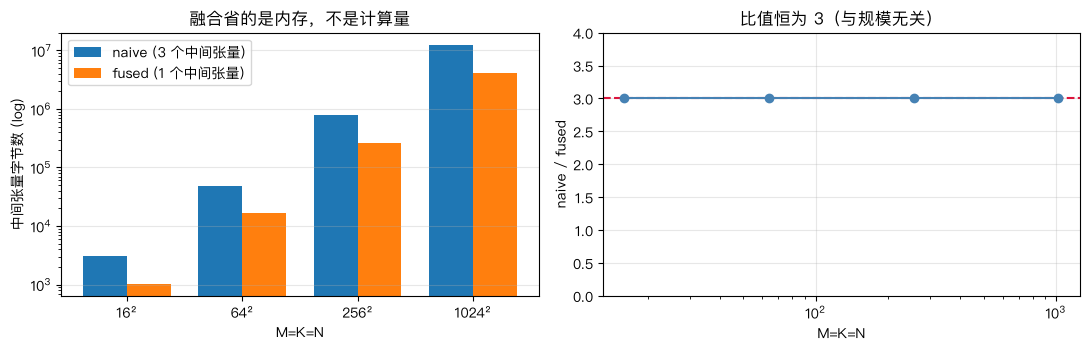

结论：融合把中间张量从 3 块降到 1 块，比值恒为 3 ——
它一丁点 FLOPs 都没省，省的全是内存往返与分配。


In [5]:
# ── 图 1 的数据 ───────────────────────────────────────────────
# naive_bytes : 原图每个规模下的中间张量总字节（mm / bias / relu 三块 [s,s] float32）
# fused_bytes : 融合图只剩 1 块 [s,s]（fused0 的输出，sin 还要读它）
# ratio       : naive / fused；这里恒等于 3，因为"省的倍数 = 被吃掉的中间张量个数"
fused_bytes = [account(fuse_graph(make_graph(s, s, s),
                                  find_fusable_groups(make_graph(s, s, s), "sin")), "sin")
               for s in SWEEP]
ratio = [a / b for a, b in zip(naive_bytes, fused_bytes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

x = np.arange(len(SWEEP))
w = 0.38
ax1.bar(x - w / 2, naive_bytes, w, label="naive (3 个中间张量)")
ax1.bar(x + w / 2, fused_bytes, w, label="fused (1 个中间张量)")
ax1.set_xticks(x, [f"{s}²" for s in SWEEP])
ax1.set_yscale("log")
ax1.set_xlabel("M=K=N")
ax1.set_ylabel("中间张量字节数 (log)")
ax1.set_title("融合省的是内存，不是计算量")
ax1.legend()
ax1.grid(axis="y", alpha=.3)

ax2.axhline(3, ls="--", color="crimson")
ax2.plot(SWEEP, ratio, "o-", color="steelblue")
ax2.set_xscale("log")
ax2.set_xlabel("M=K=N")
ax2.set_ylabel("naive / fused")
ax2.set_title("比值恒为 3（与规模无关）")
ax2.set_ylim(0, 4)
ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

print("结论：融合把中间张量从 3 块降到 1 块，比值恒为 3 ——")
print("它一丁点 FLOPs 都没省，省的全是内存往返与分配。")

---

## §5 改进 2：不解释，改"生成"——这才是"编译"

到 §4 为止我们仍然是**解释器**：运行时查 `OP_IMPL` 表、逐节点分派、每个节点都是一次 Python 函数调用。

**编译器的关键跃迁在这里：不再运行时查表解释，而是提前把整个融合组翻译成一段专用代码。**

```text
解释器:  图 + 数据  ──运行时查表──▶  结果
编译器:  图         ──编译期──▶  专用代码  ──运行时直接跑──▶  结果
```

类比 GCC/LLVM：不是运行时解释 C 语句，而是先生成机器码。

下面我们把 `matmul + bias + relu` 这个融合组**生成一段 C 源码**——注意这一步只是**字符串拼接**，跟硬件无关，它就是 codegen（代码生成）。

> **codegen**（code generation）直译"代码生成"：把编译器内部的中间表示，翻译成某种目标语言的源码或机器码。这里目标语言是 C；后面 BYOC 里，目标可以是厂商 IR、JSON、CUDA C，甚至 NPU 的指令流。

In [6]:
C_TEMPLATE_NAIVE = r"""
void {sym}(const float* X, const float* W, const float* B, float* O,
           long M, long K, long N) {{
  for (long i = 0; i < M; ++i) {{
    for (long j = 0; j < N; ++j) {{
      float acc = 0.0f;
      for (long k = 0; k < K; ++k) {{
        acc += X[i * K + k] * W[k * N + j];
      }}
      acc += B[j];                              // add(bias)
      O[i * N + j] = acc > 0.0f ? acc : 0.0f;   // relu
    }}
  }}
}}
"""


def codegen_c(symbol: str) -> str:
    """把融合组翻译成 C 源码 —— 这一步只是字符串生成，就是 codegen"""
    return C_TEMPLATE_NAIVE.format(sym=symbol)


generated = codegen_c("fused_matmul_bias_relu")
print(generated)


void fused_matmul_bias_relu(const float* X, const float* W, const float* B, float* O,
           long M, long K, long N) {
  for (long i = 0; i < M; ++i) {
    for (long j = 0; j < N; ++j) {
      float acc = 0.0f;
      for (long k = 0; k < K; ++k) {
        acc += X[i * K + k] * W[k * N + j];
      }
      acc += B[j];                              // add(bias)
      O[i * N + j] = acc > 0.0f ? acc : 0.0f;   // relu
    }
  }
}



In [7]:
import ctypes
import pathlib
import subprocess
import tempfile

WORK = pathlib.Path(tempfile.mkdtemp(prefix="toycc_"))


def compile_and_load(src: str, symbol: str):
    """把 C 源码交给系统 C 编译器编成动态库，再用 ctypes 装载。
    这就是编译器流水线最后一环：codegen → 编译 → 链接 → 可执行模块。"""
    c_path = WORK / f"{symbol}.c"
    so_path = WORK / f"{symbol}.so"
    c_path.write_text("#include <stddef.h>\n" + src)
    # -O2     : 让 C 编译器自己做优化
    # -fPIC   : 生成位置无关代码，才能被动态加载
    # -shared : 产出动态库而不是可执行文件
    subprocess.run(
        ["cc", "-O2", "-fPIC", "-shared", "-o", str(so_path), str(c_path)],
        check=True,
    )
    return ctypes.CDLL(str(so_path))


F32 = np.ctypeslib.ndpointer(dtype=np.float32, flags="C_CONTIGUOUS")
LONG = ctypes.c_long

lib = compile_and_load(generated, "fused_matmul_bias_relu")
fn = lib.fused_matmul_bias_relu
fn.argtypes = [F32, F32, F32, F32, LONG, LONG, LONG]
fn.restype = None


def call_generated(X, W, B):
    O = np.zeros((X.shape[0], W.shape[1]), dtype="float32")
    fn(X, W, B, O, X.shape[0], X.shape[1], W.shape[1])
    return O


out_c = call_generated(feeds["x"], feeds["w"], feeds["b"])
print(f"生成的 C kernel parity  max|Δ| = {np.abs(out_c - np.maximum(feeds['x'] @ feeds['w'] + feeds['b'], 0)).max():.3e}")
print(f"产物目录: {WORK}")

生成的 C kernel parity  max|Δ| = 0.000e+00
产物目录: /var/folders/v3/5gqmcs4d02d5d6wzyqyljrcc0000gn/T/toycc_tug67lbe


---

## §6 改进 3：生成的代码本身还能优化——tiling

代码能生成了，下一个问题自然来了：**生成的代码质量由谁负责？**

看 §5 生成的三重循环，循环序是 `i → j → k`。最内层读的是 `W[k*N + j]`——`k` 在变、`j` 固定，所以它是**沿着 W 的列走，步长 = N 个 float**。

用你的 cache 知识想一下：每读一个 `W` 元素就要跳 `N×4` 字节，一个 64 B 的 cache line 只命中 1 个 float，**其余 15/16 全浪费**。矩阵一大，W 根本放不进 L1/L2，于是每个 FMA 都在等 DDR。

**改进：分块（tiling / cache blocking）。** 把大矩阵切成能塞进 cache 的小块，在小块里把活干完再换下一块——这正是你熟悉的 cache blocking，只不过这里不是手写，而是**编译器在生成代码时决定的循环序与分块大小**。

> **tile / tiling**：把一个大循环切成若干小块，使每块的工作集（working set）能驻留在 cache 里；对应 GCC/LLVM 里的 loop tiling / loop blocking 优化。

In [8]:
C_TEMPLATE_TILED = r"""
#include <string.h>
void {sym}(const float* X, const float* W, const float* B, float* O,
           long M, long K, long N, long T) {{
  memset(O, 0, (size_t)M * N * sizeof(float));   // O 当累加器用，先清零

  for (long i0 = 0; i0 < M; i0 += T)             // 按 T×T 分块
    for (long k0 = 0; k0 < K; k0 += T)
      for (long j0 = 0; j0 < N; j0 += T) {{
        long iE = i0 + T < M ? i0 + T : M;
        long kE = k0 + T < K ? k0 + T : K;
        long jE = j0 + T < N ? j0 + T : N;
        for (long i = i0; i < iE; ++i)
          for (long k = k0; k < kE; ++k) {{
            float xik = X[i * K + k];            // 标量提到循环外，反复复用
            for (long j = j0; j < jE; ++j)
              O[i * N + j] += xik * W[k * N + j];// W 按行连续读
          }}
      }}

  for (long i = 0; i < M; ++i)                   // bias + relu 收尾
    for (long j = 0; j < N; ++j) {{
      float v = O[i * N + j] + B[j];
      O[i * N + j] = v > 0.0f ? v : 0.0f;
    }}
}}
"""

lib_t = compile_and_load(C_TEMPLATE_TILED.format(sym="tiled"), "tiled")
fn_t = lib_t.tiled
fn_t.argtypes = [F32, F32, F32, F32, LONG, LONG, LONG, LONG]
fn_t.restype = None


def call_tiled(X, W, B, tile):
    O = np.zeros((X.shape[0], W.shape[1]), dtype="float32")
    fn_t(X, W, B, O, X.shape[0], X.shape[1], W.shape[1], tile)
    return O


_s = 64
_X, _W, _B = (rng.standard_normal((_s, _s)).astype("float32"),
              rng.standard_normal((_s, _s)).astype("float32"),
              rng.standard_normal(_s).astype("float32"))
_ref = np.maximum(_X @ _W + _B, 0)
for t in (16, 32, 64):
    print(f"tile={t:<3} parity max|Δ| = {np.abs(call_tiled(_X, _W, _B, t) - _ref).max():.3e}")

tile=16  parity max|Δ| = 0.000e+00
tile=32  parity max|Δ| = 0.000e+00
tile=64  parity max|Δ| = 0.000e+00


In [9]:
# ── 图 2 的数据 ───────────────────────────────────────────────
# BENCH_SIZES : 参与基准的方阵规模 M=K=N
# TILES       : 参与比较的分块大小
# t_naive     : §5 生成的 i→j→k 循环（未分块）的最优耗时（秒）
# t_tiled[t]  : tiled 版在分块大小 t 下的最优耗时（秒）
# t_numpy     : numpy/BLAS 的参考线 —— 只作参照，不拿来算"加速比"
BENCH_SIZES = [128, 256, 512]
TILES = [32, 64, 128]
REPS = 3


def bench(callable_, reps=REPS):
    """取多次里最好的一次，减少调度噪声"""
    best = float("inf")
    for _ in range(reps):
        t0 = time.perf_counter()
        callable_()
        best = min(best, time.perf_counter() - t0)
    return best


t_naive, t_numpy = [], []
t_tiled = {t: [] for t in TILES}

for s in BENCH_SIZES:
    X = rng.standard_normal((s, s)).astype("float32")
    W = rng.standard_normal((s, s)).astype("float32")
    B = rng.standard_normal(s).astype("float32")
    r = np.maximum(X @ W + B, 0)

    o1 = call_generated(X, W, B)
    t_naive.append(bench(lambda: call_generated(X, W, B)))
    t_numpy.append(bench(lambda: np.maximum(X @ W + B, 0)))
    for t in TILES:
        ot = call_tiled(X, W, B, t)
        t_tiled[t].append(bench(lambda: call_tiled(X, W, B, t)))
        # 每一档都过正确性，速度再快结果错了也毫无意义
        assert np.allclose(ot, r, rtol=1e-3, atol=1e-3), f"size={s} tile={t} 结果不符"
    assert np.allclose(o1, r, rtol=1e-3, atol=1e-3), f"size={s} naive 结果不符"

print("全部档位 parity 通过（rtol=atol=1e-3）")
print(f"\n{'size':>6}{'naive(ms)':>12}" + "".join(f"{'tile'+str(t):>11}" for t in TILES) + f"{'numpy(ms)':>12}")
for i, s in enumerate(BENCH_SIZES):
    row = f"{s:>6}{t_naive[i]*1e3:>12.2f}"
    row += "".join(f"{t_tiled[t][i]*1e3:>11.2f}" for t in TILES)
    row += f"{t_numpy[i]*1e3:>12.2f}"
    print(row)

全部档位 parity 通过（rtol=atol=1e-3）

  size   naive(ms)     tile32     tile64    tile128   numpy(ms)
   128        2.78       0.65       0.35       0.24        1.19
   256       22.03       4.72       1.73       1.29        0.20
   512      149.69      23.83      18.92      11.28        1.40


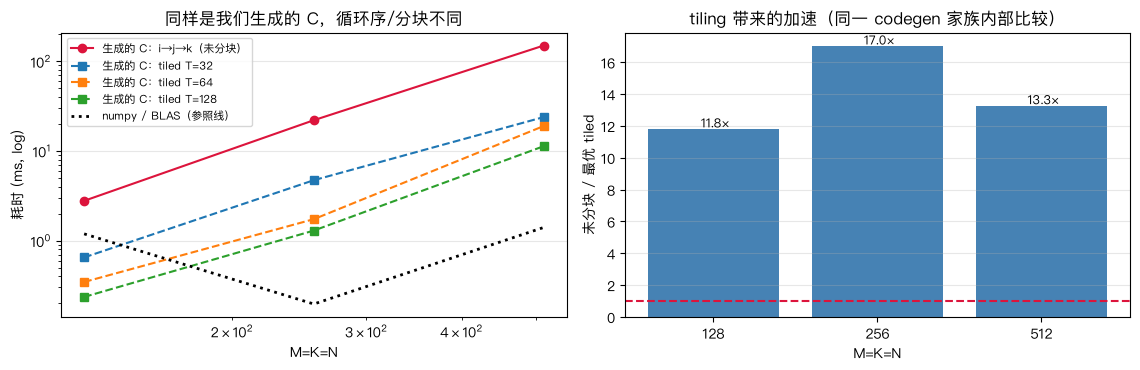

诚实说明：
  · tiled 最快档仍是 numpy/BLAS 的 8× 慢
  · 所以这份 C 的价值是'证明 codegen + tiling 的机制'，不是'写出比 BLAS 快的 kernel'
  · 拿它跟 BLAS 比'加速比'就是伪证据 —— 那要由 autotuning + 向量化 + 多线程来做，见 05


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax1.plot(BENCH_SIZES, [t * 1e3 for t in t_naive], "o-", color="crimson", label="生成的 C：i→j→k（未分块）")
for t in TILES:
    ax1.plot(BENCH_SIZES, [v * 1e3 for v in t_tiled[t]], "s--", label=f"生成的 C：tiled T={t}")
ax1.plot(BENCH_SIZES, [t * 1e3 for t in t_numpy], "k:", lw=2, label="numpy / BLAS（参照线）")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("M=K=N"); ax1.set_ylabel("耗时 (ms, log)")
ax1.set_title("同样是我们生成的 C，循环序/分块不同")
ax1.legend(fontsize=8); ax1.grid(alpha=.3)

# speedup : 未分块 / 最好那档 tiled —— 只在"我们自己生成的代码之间"比
speedup = [a / min(t_tiled[t][i] for t in TILES) for i, a in enumerate(t_naive)]
ax2.bar([str(s) for s in BENCH_SIZES], speedup, color="steelblue")
ax2.axhline(1, color="crimson", ls="--")
ax2.set_xlabel("M=K=N"); ax2.set_ylabel("未分块 / 最优 tiled")
ax2.set_title("tiling 带来的加速（同一 codegen 家族内部比较）")
ax2.grid(axis="y", alpha=.3)
for i, v in enumerate(speedup):
    ax2.text(i, v, f" {v:.1f}×", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("诚实说明：")
print(f"  · tiled 最快档仍是 numpy/BLAS 的 {max(t_tiled[TILES[-1]][i] / t_numpy[i] for i in range(len(BENCH_SIZES))):.0f}× 慢")
print("  · 所以这份 C 的价值是'证明 codegen + tiling 的机制'，不是'写出比 BLAS 快的 kernel'")
print("  · 拿它跟 BLAS 比'加速比'就是伪证据 —— 那要由 autotuning + 向量化 + 多线程来做，见 05")

---

## §7 小结：我们手搓的"编译器"缺什么

走完了 `建图 → 解释 → 融合 → 生成 → 分块`。它已经是一个能跑的最小编译器了，但离能用在真实模型上还差得很远：

| 我们手搓的 | 缺什么能力 | 后果 |
|---|---|---|
| `shape` 硬编码在 `make_graph` 里 | **shape / dtype 自动推导** | 换个 shape 就得改代码；无法处理动态 batch |
| `FUSE_CHAIN` 写死一条链 | **通用 pattern 描述语言 + 自动匹配** | 换一个模型就要重写融合器 |
| 只有"融合"这一招 | **可插拔、可组合的 Pass 框架** | 优化无法复用、无法排序、无法开关 |
| C 源码是字符串拼的 | **低层 IR（TIR）+ 调度原语** | `T` 写死在代码里，无法自动搜索最优分块 |
| 只能生成 C、只能跑 CPU | **多 target codegen + 统一 runtime 抽象** | 换 NPU 要重写整条链 |
| 每个中间结果各自 `np.zeros` | **静态内存规划 / buffer 复用** | 峰值内存高，分配器抖动 |
| 手工 print 几个 parity | **逐层 parity + 负控 + golden 回归** | 出错定位不到层，改一次回归一次 |
| 只用 `time.perf_counter` | **profiling + cost model + autotuning** | 不知道快不快、更不知道为什么 |

**下一本 notebook（03）就回答：TVM 是怎么把这 8 项一个个补齐的。**

---

## 检视与验证清单（你可以自己复现）

| 想看什么 | 怎么做 |
|---|---|
| 生成的 C 源码 | `print(codegen_c("fused_matmul_bias_relu"))` |
| 编译产物在哪 | `print(WORK)`，里面有 `.c` 和 `.so` |
| 用命令行自己编一遍 | `cc -O2 -fPIC -shared -o /tmp/k.so <那个 .c 文件>` |
| 反汇编看看编译器做了什么 | `objdump -d --no-show-raw-insn /tmp/k.so \| head -60` |
| 换循环序再测一次 | 把 `C_TEMPLATE_NAIVE` 的三重循环改成 `i→k→j`，重跑 §6 的 bench |

In [11]:
print("=" * 66)
print(" 手搓迷你编译器 · 能力清单")
print("=" * 66)
rows = [
    ("建图 (DAG + 拓扑排序)", "✅ 手搓完成"),
    ("逐算子解释执行", "✅ 手搓完成"),
    ("算子融合", "✅ 手搓完成（固定链）"),
    ("代码生成 (C)", "✅ 手搓完成（字符串模板）"),
    ("循环分块 (tiling)", "✅ 手搓完成（T 手写指定）"),
    ("shape / dtype 推导", "❌ 交给 TVM 的 StructInfo"),
    ("通用 pattern 匹配", "❌ 交给 TVM 的 DPL + FuseOpsByPattern"),
    ("低层 IR 与调度空间", "❌ 交给 TVM 的 TIR + schedule"),
    ("多 target / runtime", "❌ 交给 TVM 的 codegen + runtime.Module"),
    ("内存规划 / autotuning", "❌ 交给 TVM 的 memory planning + AutoTuning"),
]
for k, v in rows:
    print(f"  {k:<28} {v}")
print("=" * 66)


 手搓迷你编译器 · 能力清单
  建图 (DAG + 拓扑排序)              ✅ 手搓完成
  逐算子解释执行                      ✅ 手搓完成
  算子融合                         ✅ 手搓完成（固定链）
  代码生成 (C)                     ✅ 手搓完成（字符串模板）
  循环分块 (tiling)                ✅ 手搓完成（T 手写指定）
  shape / dtype 推导             ❌ 交给 TVM 的 StructInfo
  通用 pattern 匹配                ❌ 交给 TVM 的 DPL + FuseOpsByPattern
  低层 IR 与调度空间                  ❌ 交给 TVM 的 TIR + schedule
  多 target / runtime           ❌ 交给 TVM 的 codegen + runtime.Module
  内存规划 / autotuning            ❌ 交给 TVM 的 memory planning + AutoTuning
